# D4.1 Position, Velocity, and Acceleration in Polar Coordinates
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D4.1.1 Motivation: Why Polar Coordinates?

When we first encounter kinematics, motion is almost always described in Cartesian coordinates: position along $x$, $y$, and sometimes $z$ axes. This is natural, since many problems in introductory physics involve objects moving along straight lines or simple paths where Cartesian coordinates provide the most direct description.

However, as soon as we begin to study motion that involves curvature—such as:

- circular motion  
- orbital motion (planets, satellites)  
- motion under central forces  
- particles constrained to curved paths  

the Cartesian system becomes cumbersome. In these situations:

- the motion is not aligned with the coordinate axes  
- constraints are often expressed in terms of **distance from a point** or **angles**

As a result, describing motion using $(x,y)$ requires continuously recombining components to recover the actual physical behavior.

---

In these cases, it is more natural to describe motion relative to a **central point** using **polar coordinates**

$$
(r,\theta),
$$

where:

- $r$ represents the **distance from the origin**  
- $\theta$ represents the **angular position**

This coordinate system aligns directly with the geometry of curved motion.

The power of polar coordinates lies in how they separate motion into two intuitive parts:

- **radial motion** → movement inward or outward  
- **transverse (angular) motion** → rotation about the origin  

Instead of tracking $x$ and $y$ separately, we describe motion through how $r(t)$ and $\theta(t)$ evolve.

This makes it straightforward to separate the kinematics into two intuitive parts: radial motion (inward or outward) and transverse motion (rotation around the origin). The resulting velocity and acceleration expressions reveal new terms, such as the centripetal and Coriolis, like contributions—that emerge naturally from the mathematics, and which are indispensable in understanding rotational and orbital systems.

---

In short, polar coordinates provide a language that matches the **symmetry of rotational and orbital motion**. They:

- simplify the mathematical description of curved trajectories  
- reveal the physical structure of motion  
- prepare us to analyze systems governed by **central forces**

By mastering kinematics in polar coordinates, we gain tools that will be essential for understanding:

- orbital motion  
- angular momentum  
- effective potentials  
- and later, Lagrangian mechanics  

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D4.1.2 Setup: What Changes from Cartesian Coordinates?

In Cartesian coordinates:

- unit vectors $\hat{\mathbf{x}}, \hat{\mathbf{y}}$ are **constant**  
- only the coordinates change with time  

In polar coordinates:

- the coordinates $r(t)$ and $\theta(t)$ change  
- **the unit vectors also change with time**

This is the key difference that leads to new terms in velocity and acceleration.

---

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Definition — Polar Unit Vectors</h3>

- $\hat{\mathbf{r}}$ points **radially outward**  
- $\hat{\boldsymbol{\theta}}$ points **perpendicular to $\hat{\mathbf{r}}$**, in the direction of increasing $\theta$

These unit vectors **rotate as the particle moves**.

</div>

The figure below shows the relationship between the cartesian and polar unit vectors. We will use this to derive the velocity and acceleration in polar coordinates.


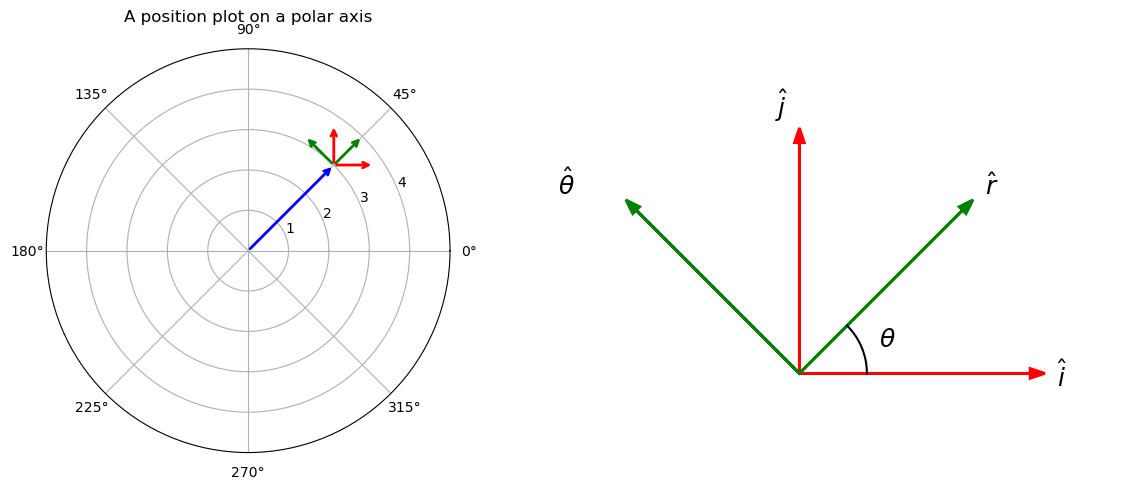

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Setup
# -----------------------------
fig = plt.figure(figsize=(12, 5))

theta = np.deg2rad(45)
r = 3.0

# Position in Cartesian coordinates
x0 = r * np.cos(theta)
y0 = r * np.sin(theta)

# Unit vectors at the particle location
r_hat = np.array([np.cos(theta), np.sin(theta)])
theta_hat = np.array([-np.sin(theta), np.cos(theta)])
i_hat = np.array([1.0, 0.0])
j_hat = np.array([0.0, 1.0])

# ==================================================
# LEFT: Polar grid with correctly drawn local unit vectors
# ==================================================
ax1 = fig.add_subplot(1, 2, 1, projection="polar")

ax1.set_title("A position plot on a polar axis", pad=20)
ax1.set_rmax(5)
ax1.set_rticks([1, 2, 3, 4])
ax1.set_rlabel_position(22.5)
ax1.grid(True)

# Position vector
ax1.annotate(
    "",
    xy=(theta, r),
    xytext=(0, 0),
    arrowprops=dict(arrowstyle="->", color="blue", lw=2)
)

# Helper: draw a true Cartesian arrow on a polar plot
def cart_arrow_on_polar(ax, start_xy, vec_xy, color, lw=2):
    end_xy = start_xy + vec_xy

    start_theta = np.arctan2(start_xy[1], start_xy[0])
    start_r = np.sqrt(start_xy[0]**2 + start_xy[1]**2)

    end_theta = np.arctan2(end_xy[1], end_xy[0])
    end_r = np.sqrt(end_xy[0]**2 + end_xy[1]**2)

    ax.annotate(
        "",
        xy=(end_theta, end_r),
        xytext=(start_theta, start_r),
        arrowprops=dict(arrowstyle="->", color=color, lw=lw)
    )

start = np.array([x0, y0])
arrow_len = 1.0

# True unit vectors of length 1
cart_arrow_on_polar(ax1, start, arrow_len * r_hat, "green")
cart_arrow_on_polar(ax1, start, arrow_len * theta_hat, "green")

# True Cartesian unit vectors of length 1
cart_arrow_on_polar(ax1, start, arrow_len * i_hat, "red")
cart_arrow_on_polar(ax1, start, arrow_len * j_hat, "red")

# ==================================================
# RIGHT: Unit vector diagram
# ==================================================
ax2 = fig.add_subplot(1, 2, 2)
ax2.set_aspect("equal")
ax2.axis("off")

def draw_arrow(ax, start, vec, color, label=None, label_offset=(0, 0)):
    ax.arrow(
        start[0], start[1],
        vec[0], vec[1],
        head_width=0.08,
        head_length=0.12,
        length_includes_head=True,
        color=color,
        linewidth=2
    )
    if label is not None:
        ax.text(
            start[0] + vec[0] + label_offset[0],
            start[1] + vec[1] + label_offset[1],
            label,
            fontsize=18
        )

origin = np.array([0.0, 0.0])
scale = 2.0

# Cartesian basis
draw_arrow(ax2, origin, scale * i_hat, "red", r"$\hat{i}$", (0.1, -0.1))
draw_arrow(ax2, origin, scale * j_hat, "red", r"$\hat{j}$", (-0.2, 0.1))

# Polar basis
draw_arrow(ax2, origin, scale * r_hat, "green", r"$\hat{r}$", (0.1, 0.05))
draw_arrow(ax2, origin, scale * theta_hat, "green", r"$\hat{\theta}$", (-0.55, 0.05))

# Angle arc
arc_radius = 0.55
arc_angles = np.linspace(0, theta, 100)
ax2.plot(
    arc_radius * np.cos(arc_angles),
    arc_radius * np.sin(arc_angles),
    color="black",
    lw=1.5
)
ax2.text(0.65, 0.22, r"$\theta$", fontsize=18)

ax2.set_xlim(-2.0, 2.6)
ax2.set_ylim(-0.6, 2.6)

plt.tight_layout()
plt.show()

The blue vector represents a position vector $\vec{r}$. The two red vectors are the cartesian unit vectors $\hat{i}$ and $\hat{j}$, while the green vectors are the polar unit vectors $\hat{r}$ and $\hat{\theta}$. In contrast to the cartesian unit vectors, the polar unit vectors are changing directions depending on the position vector. The radial unit vector $\hat{r}$ is always pointing in the radial direction away from the origin, and the angular unit vector $\hat{\theta}$ is always pointing in the counterclockwise angular direction.

The position vector is fully characterized by

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Definition — Polar Position Vector</h3>

$$ \vec{r} = r\hat{r} \tag{1}$$

</div>

<br>
This appears simpler than the cartesian version: $\vec{r} = x\hat{i} + y\hat{j}$, but do not be fooled. Whereas the cartesian unit vectors are constant, the $\hat{r}$ unit vector is a function of $\theta$ and makes it a lot more complex as we will see.

From the sketch on the right, we can write the polar unit vectors in terms of the cartesian unit vectors:
<br>

\begin{eqnarray*}
 \hat{r} &=& \cos\theta\hat{i} + \sin\theta\hat{j} \tag{2}
\\
 \hat{\theta} &=& -\sin\theta\hat{i} + \cos\theta\hat{j} \tag{3}
\end{eqnarray*}

In the following, we will need to know the time derivative of the polar unit vectors:

### Time Derivative of $\hat{r}$

We will be using the *dot* notation for time derivatives.

Applying the sum, product, and chain rules on Equation(2):

$$ \dot{\hat{r}} = -\dot{\theta}\sin\theta\hat{i} + \cos\theta\dot{\hat{i}} + \dot{\theta}\cos\theta\hat{j} + \cos\theta\dot{\hat{j}}$$

Since the cartesian unit vectors are constants, their time-derivative is zero:

$$ \dot{\hat{r}} = -\dot{\theta}\sin\theta\hat{i} + \dot{\theta}\cos\theta\hat{j} $$

Pulling out the common factor of $\dot{\theta}$:

$$ \dot{\hat{r}} = \dot{\theta}\left(-\sin\theta\hat{i} + \cos\theta\hat{j}\right) $$

The term in the parenthesis is the same as $\hat{\theta}$:

$$ \dot{\hat{r}} = \dot{\theta}\hat{\theta} \tag{4}$$

<div style="background-color:#e8f5e9; border-left:5px solid #006633; padding:12px; border-radius:4px;">
<h3 style="margin-top:0; color:#000000;">Box Activity 1 — Time Derivative of $\hat{\boldsymbol{\theta}}$</h3>

In this activity, you will derive the time derivative of the polar unit vector $\hat{\boldsymbol{\theta}}$ using its Cartesian representation.

---

**Task**

Start from

$$
\hat{\boldsymbol{\theta}} = -\sin\theta\,\hat{i} + \cos\theta\,\hat{j}.
$$

Use calculus and the properties of Cartesian unit vectors to determine $\dot{\hat{\boldsymbol{\theta}}}$.

---

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Solution
</summary>

<div style="background-color:#e8f5e9; padding:10px; border-radius:4px; margin-top:6px;">

**Step 1 — Differentiate**

Apply the product rule:

$$
\dot{\hat{\theta}} =
-\dot{\theta}\cos\theta\,\hat{i}
-\sin\theta\,\dot{\hat{i}}
-\dot{\theta}\sin\theta\,\hat{j}
+\cos\theta\,\dot{\hat{j}}.
$$

---

**Step 2 — Use constant Cartesian unit vectors**

$$
\dot{\hat{i}} = 0, \quad \dot{\hat{j}} = 0
$$

So

$$
\dot{\hat{\theta}} =
-\dot{\theta}\cos\theta\,\hat{i}
-\dot{\theta}\sin\theta\,\hat{j}.
$$

---

**Step 3 — Factor out $\dot{\theta}$**

$$
\dot{\hat{\theta}} =
-\dot{\theta}\left(\cos\theta\,\hat{i} + \sin\theta\,\hat{j}\right).
$$

---

**Step 4 — Recognize $\hat{\mathbf{r}}$**

$$
\hat{\mathbf{r}} = \cos\theta\,\hat{i} + \sin\theta\,\hat{j}
$$

Thus

$$
\dot{\hat{\theta}} = -\dot{\theta}\hat{\mathbf{r}}.
$$

---

**Final Result**

$$
\boxed{
\dot{\hat{\boldsymbol{\theta}}} = -\dot{\theta}\hat{\mathbf{r}}
}
$$

---

**Interpretation**

- $\hat{\boldsymbol{\theta}}$ rotates toward $-\hat{\mathbf{r}}$  
- The rate of change is proportional to the angular speed $\dot{\theta}$  

</div>
</details>

</div>

---

We are now ready to explore velocity and acceleration in polar coordinates.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D4.1.3 Velocity Vector in Polar Coordinates

We take the time-derivate of the position vector in Equation (1):

$$ \dot{\vec{r}} = \dot{r}\hat{r} + r\dot{\hat{r}} $$

Insert Equation (4):

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Derived — Polar Velocity Vector</h3>

$$ \dot{\vec{r}} = \dot{r}\hat{r} + r\dot{\theta}\hat{\theta} \tag{6}$$
</div>
    
### Discussion

#### Radial Term
The radial term is the one associated with $\hat{r}$:

$$ \vec{v}_r = \dot{r}\hat{r} $$

This tells us that the radial velocity is the rate of change of the distance away from the origin. This is simply a straight line velocity as on object moves towards/away the origin in a straight line. 

#### Transverse Term

The transverse term is the one associated with $\hat{\theta}$:

$$ \vec{v}_{\theta} = r\dot{\theta}\hat{\theta} $$

We may recognise $\dot\theta$ is the angular speed $\omega$ and we can rewrite

$$ \vec{v}_{\theta} = r\omega\hat{\theta} $$

with a magnitude of

$$ v_{\theta} = r\omega $$

What a hoot: this is what we called the tangential speed in the University Physics.

#### Circular Motion

If we have circular motion, the radial component is zero and we are left with only the transverse velocity:

$$ \vec{v} = r\dot\theta\hat{\theta}$$

---

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Velocity in Polar Coordinates</h3>

<strong>Problem</strong>  

$$
r(t)=t^2, \quad \theta(t)=2t
$$

---

<strong>Solution</strong>

$$
\dot{r}=2t, \quad \dot{\theta}=2
$$

$$
\mathbf{v}=2t\hat{\mathbf{r}}+2t^2\hat{\boldsymbol{\theta}}
$$

</div>

---

<div style="background-color:#e8f5e9; border-left:5px solid #006633; padding:12px; border-radius:4px;">
<h3 style="margin-top:0;">Box Activity 2 — Interpreting Velocity</h3>

A particle has velocity

$$
\mathbf{v}=4\,\hat{\mathbf{r}}+3\,\hat{\boldsymbol{\theta}} \quad (\text{m/s})
$$

---

1. What is the **radial speed**?  
2. What is the **tangential speed**?  
3. What is the **direction of motion**?

---

<details>
<summary style="background-color:#006633; color:white; padding:8px;">Solution</summary>

<div style="background-color:#e8f5e9; padding:10px; border-radius:4px; margin-top:6px;">

The velocity is already expressed in polar components:

$$
\mathbf{v}=v_r\,\hat{\mathbf{r}} + v_\theta\,\hat{\boldsymbol{\theta}}
$$

---

**Radial speed**

$$
v_r = 4 \ \text{m/s}
$$

→ The particle is moving **outward**.

---

**Tangential speed**

$$
v_\theta = 3 \ \text{m/s}
$$

→ The particle is moving **around the origin**.

---

**Direction of motion**

The velocity has both:

- outward motion (radial)  
- rotational motion (tangential)  

Since both components are positive:

- motion is **away from the origin**  
- motion is in the **direction of increasing $\theta$**

---

</div>
</details>
</div>

---

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0; color:#000000;">Example — Velocity in Polar Coordinates</h3>

<strong>Problem</strong>  

A particle moves such that

$$
r(t) = 1 + t^2, \quad \theta(t) = 2t.
$$

Determine the velocity vector $\mathbf{v}$ at time $t = 1$.

---

<strong>Solution</strong>

We use

$$
\mathbf{v} = \dot{r}\,\hat{\mathbf{r}} + r\dot{\theta}\,\hat{\boldsymbol{\theta}}.
$$

---

<strong>Step 1 — Compute derivatives</strong>

$$
\dot{r} = 2t, \quad \dot{\theta} = 2.
$$

At $t=1$:

$$
\dot{r} = 2, \quad \dot{\theta} = 2.
$$

---

<strong>Step 2 — Evaluate $r$</strong>

$$
r(1) = 1 + (1)^2 = 2.
$$

---

<strong>Step 3 — Substitute into velocity expression</strong>

$$
\mathbf{v} = 2\,\hat{\mathbf{r}} + (2)(2)\,\hat{\boldsymbol{\theta}}.
$$

$$
\mathbf{v} = 2\,\hat{\mathbf{r}} + 4\,\hat{\boldsymbol{\theta}}.
$$

---

<strong>Final Result</strong>

$$
\boxed{
\mathbf{v} = 2\,\hat{\mathbf{r}} + 4\,\hat{\boldsymbol{\theta}}
}
$$

---

<strong>Interpretation</strong>

- The particle is moving **outward** (positive radial component)  
- It also has a **tangential motion** around the origin  
- The tangential speed is larger than the radial speed, so the motion is dominated by rotation  

</div>

<br>
Let us try and plot this path in both cartesian and polar coordinates.

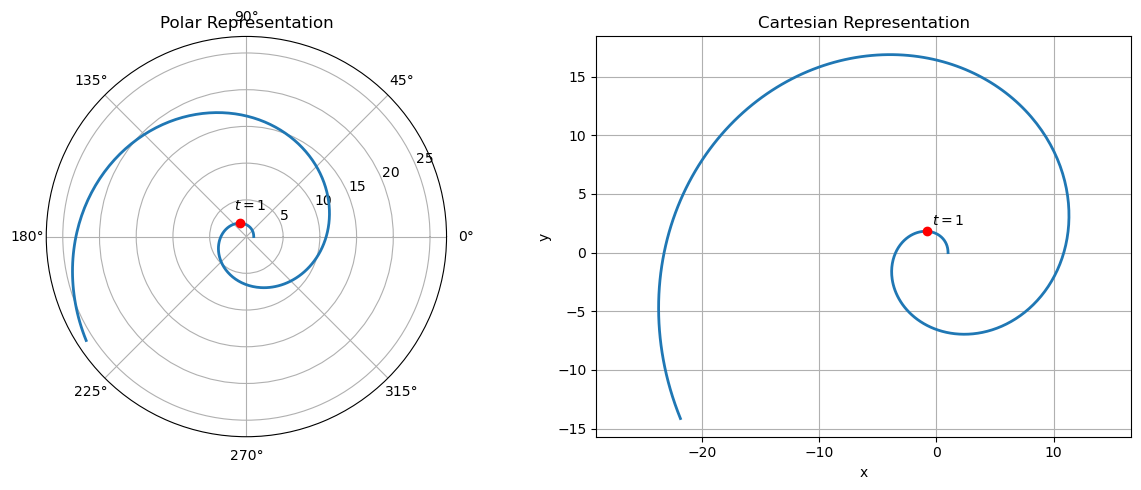

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Time array
# -----------------------------
t = np.linspace(0, 5, 400)

# Polar functions
r = 1 + t**2
theta = 2*t

# Convert to Cartesian
x = r * np.cos(theta)
y = r * np.sin(theta)

# Point at t = 1
t0 = 1
r0 = 1 + t0**2
theta0 = 2*t0
x0 = r0 * np.cos(theta0)
y0 = r0 * np.sin(theta0)

# -----------------------------
# Create figure
# -----------------------------
fig = plt.figure(figsize=(12, 5))

# ==================================================
# LEFT: Polar plot
# ==================================================
ax1 = fig.add_subplot(1, 2, 1, projection='polar')

ax1.plot(theta, r, linewidth=2)
ax1.scatter(theta0, r0, color='red', zorder=5)

ax1.annotate(
    r"$t=1$",
    xy=(theta0, r0),
    xytext=(theta0, r0 + 2)
)

ax1.set_title("Polar Representation")
ax1.grid(True)

# ==================================================
# RIGHT: Cartesian plot
# ==================================================
ax2 = fig.add_subplot(1, 2, 2)

ax2.plot(x, y, linewidth=2)
ax2.scatter(x0, y0, color='red', zorder=5)

ax2.annotate(
    r"$t=1$",
    xy=(x0, y0),
    xytext=(x0 + 0.5, y0 +0.5)
)

ax2.set_title("Cartesian Representation")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.axis("equal")
ax2.grid(True)

# -----------------------------
# Show
# -----------------------------
plt.tight_layout()
plt.show()

---

After plotting the same motion in both coordinate systems, we observe something subtle but important:

- The **polar plot** represents the motion in $(r,\theta)$  
- The **Cartesian plot** represents the motion in $(x,y)$  

Both plots describe the **same trajectory in physical space**.

In many cases—such as the example above—the overall shape of the curve appears very similar. This is not surprising, since both are visualizing the same set of points.

---

### What is actually being plotted?

The key difference lies in how the axes are interpreted.

- In the **Cartesian plot**, the axes are linear directions in space:
  
  $$
  x \quad \text{and} \quad y
  $$

- In the **polar plot**, the axes are:

  $$
  r \quad \text{and} \quad \theta
  $$

Both coordinate systems describe the same physical space. Neither is more “real” than the other.

---

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Definition — Trajectory vs Representation</h3>

- A **trajectory** is the path of a particle in physical space  
- A **representation** is how we describe that path using coordinates  

Different coordinate systems give **different mathematical descriptions of the same trajectory**.

</div>

---

### Why the plots can appear different

Although the trajectory itself is unchanged, the **visual representation** depends on how the coordinates are mapped to the plot.

The transformation between coordinate systems is nonlinear:

$$
x = r\cos\theta, \quad y = r\sin\theta.
$$

Because of this:

- equal steps in $\theta$ do not correspond to equal distances in space  
- the coordinate grid in a polar plot is **curved**, not linear  
- visual spacing and scaling can distort how the path appears  

Thus, differences in appearance arise from the **plotting framework**, not from any change in the motion.

---

### What is “real”?

<div style="background-color:#fff8e1; border-left:6px solid #ffc20e; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Curiosity — What Is the Real Motion?</h3>

Neither the polar plot nor the Cartesian plot is “more real.”

They represent the **same physical trajectory**.

What is real is:

- the particle’s position as a function of time  
- the physical laws governing its motion  

The coordinate system is simply a **choice of description**, and the plot is a **choice of visualization**.

</div>

---

### Connection to invariance

This connects directly to a central idea in physics:

$$
\text{Physical laws do not depend on the coordinate system used to describe them.}
$$

Changing coordinates changes the **mathematical form** and the **visual representation**, but not the **physical motion**.

---

<div style="background-color:#fff8e1; border-left:6px solid #ffc20e; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Curiosity — Why Radial and Angular Motion Are Coupled</h3>

In Cartesian coordinates, motion in different directions is independent:

$$
\vec{v} = v_x \hat{i} + v_y \hat{j}
$$

- $\hat{i}$ and $\hat{j}$ are constant  
- changing $v_x$ does not affect motion in the $y$-direction  

---

**What changes in polar coordinates?**

In polar coordinates,

$$
\vec{v} = \dot{r}\hat{r} + r\dot{\theta}\hat{\theta}
$$

but the unit vectors satisfy

$$
\dot{\hat{r}} = \dot{\theta}\hat{\theta}, \quad
\dot{\hat{\theta}} = -\dot{\theta}\hat{r}.
$$

👉 The directions themselves are changing.

---

**The key consequence**

Because the basis vectors rotate:

- moving outward changes the **direction of motion**  
- rotating changes the **direction of radial motion**

This means:

> Motion in one “direction” automatically affects the other.

---

**Where the coupling appears**

When computing acceleration, this leads to the term

$$
2\dot{r}\dot{\theta}
$$

in the $\hat{\theta}$ direction.

This term exists **only because the unit vectors are changing**.

---

**Why this matters**

Even if

$$
\ddot{\theta} = 0,
$$

the particle can still have angular acceleration.

👉 Angular motion is influenced by **radial motion**, and vice versa.

---

**Big picture**

- In Cartesian coordinates → directions are fixed → motion decouples  
- In polar coordinates → directions rotate → motion couples  

</div>

---

<div style="background-color:#fff8e1; border-left:6px solid #ffc20e; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Important Distinction — Two Types of Coupling</h3>

- In Cartesian coordinates, one component (e.g., $v_y$) can depend on another variable (e.g., $x$).  
  → This comes from the **physics of the system**

- In polar coordinates, coupling appears even if the motion is simple  
  → This comes from the **changing direction of the unit vectors**

>Same idea of “dependence” — different origin

</div>

---

### Final insight

The coupling is not due to forces — it is due to geometry.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D4.1.4 Acceleration Vector in Polar Coordinates

<div style="background-color:#e8f5e9; border-left:5px solid #006633; padding:12px; border-radius:4px;">
<h3 style="margin-top:0; color:#000000;">Box Activity 3 — Deriving Acceleration in Polar Coordinates</h3>

In this activity, you will derive the acceleration vector in polar coordinates by differentiating the velocity vector.

Start with the polar velocity expression:

$$
\dot{\vec{r}} 
= \dot{r}\hat{r} + r\dot{\theta}\hat{\theta}.
$$

Use the unit-vector derivative relations:

$$
\dot{\hat{r}} = \dot{\theta}\hat{\theta}
$$

and

$$
\dot{\hat{\theta}} = -\dot{\theta}\hat{r}.
$$

---

**Task**

Differentiate

$$
\vec{v} = \dot{r}\hat{r} + r\dot{\theta}\hat{\theta}
$$

with respect to time and show that

$$
\ddot{\vec{r}} =
\left( \ddot{r} - r\dot{\theta}^2 \right)\hat{r}
+
\left( 2\dot{r}\dot{\theta} + r\ddot{\theta} \right)\hat{\theta}.
$$

---

<details>
<summary style="background-color:#006633; color:white; padding:8px; border-radius:4px; cursor:pointer;">
Solution
</summary>

<div style="background-color:#e8f5e9; padding:10px; border-radius:4px; margin-top:6px;">

We begin with

$$
\vec{v} = \dot{r}\hat{r} + r\dot{\theta}\hat{\theta}.
$$

Acceleration is the time derivative of velocity:

$$
\vec{a} = \frac{d\vec{v}}{dt}.
$$

Therefore,

$$
\vec{a}
=
\frac{d}{dt}\left(\dot{r}\hat{r}\right)
+
\frac{d}{dt}\left(r\dot{\theta}\hat{\theta}\right).
$$

---

**Step 1 — Differentiate the radial velocity term**

Using the product rule,

$$
\frac{d}{dt}\left(\dot{r}\hat{r}\right)
=
\ddot{r}\hat{r}
+
\dot{r}\dot{\hat{r}}.
$$

Since

$$
\dot{\hat{r}} = \dot{\theta}\hat{\theta},
$$

we get

$$
\frac{d}{dt}\left(\dot{r}\hat{r}\right)
=
\ddot{r}\hat{r}
+
\dot{r}\dot{\theta}\hat{\theta}.
$$

---

**Step 2 — Differentiate the angular velocity term**

Now differentiate

$$
r\dot{\theta}\hat{\theta}.
$$

Using the product rule,

$$
\frac{d}{dt}\left(r\dot{\theta}\hat{\theta}\right)
=
\frac{d}{dt}\left(r\dot{\theta}\right)\hat{\theta}
+
r\dot{\theta}\dot{\hat{\theta}}.
$$

First,

$$
\frac{d}{dt}\left(r\dot{\theta}\right)
=
\dot{r}\dot{\theta}
+
r\ddot{\theta}.
$$

Also,

$$
\dot{\hat{\theta}} = -\dot{\theta}\hat{r}.
$$

Therefore,

$$
\frac{d}{dt}\left(r\dot{\theta}\hat{\theta}\right)
=
\left(\dot{r}\dot{\theta}+r\ddot{\theta}\right)\hat{\theta}
-
r\dot{\theta}^2\hat{r}.
$$

---

**Step 3 — Combine terms**

Now add both contributions:

$$
\vec{a}
=
\left(\ddot{r}\hat{r}
+
\dot{r}\dot{\theta}\hat{\theta}\right)
+
\left[
\left(\dot{r}\dot{\theta}+r\ddot{\theta}\right)\hat{\theta}
-
r\dot{\theta}^2\hat{r}
\right].
$$

Group the $\hat{r}$ terms:

$$
\ddot{r}\hat{r}
-
r\dot{\theta}^2\hat{r}
=
\left(\ddot{r}-r\dot{\theta}^2\right)\hat{r}.
$$

Group the $\hat{\theta}$ terms:

$$
\dot{r}\dot{\theta}\hat{\theta}
+
\left(\dot{r}\dot{\theta}+r\ddot{\theta}\right)\hat{\theta}
=
\left(2\dot{r}\dot{\theta}+r\ddot{\theta}\right)\hat{\theta}.
$$

Thus,

$$
\boxed{
\ddot{\vec{r}} =
\left( \ddot{r} - r\dot{\theta}^2 \right)\hat{r}
+
\left( 2\dot{r}\dot{\theta} + r\ddot{\theta} \right)\hat{\theta}
}
$$

---

**Interpretation**

The radial component is

$$
a_r = \ddot{r} - r\dot{\theta}^2.
$$

The term

$$
-r\dot{\theta}^2
$$

is the familiar **centripetal acceleration** term.

The angular component is

$$
a_\theta = 2\dot{r}\dot{\theta} + r\ddot{\theta}.
$$

The term

$$
2\dot{r}\dot{\theta}
$$

appears because the radial and angular motions are coupled in polar coordinates.

</div>
</details>

</div>

---

### Discussion

We have two terms in the polar acceleration:

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Definition — Polar Acceleration Components</h3>

$$
a_r = \ddot{r} - r\dot{\theta}^2
$$

$$
a_\theta = r\ddot{\theta} + 2\dot{r}\dot{\theta}
$$

</div>

#### Radial Terms
The radial terms are the ones associated with $\hat{r}$:

$$ \vec{a}_r = \left( \ddot{r} - r\dot{\theta}^2 \right)\hat{r} $$

*Linear Acceleration*

The term

$$ \ddot{r}\hat{r} $$ 

is the **linear acceleration** as it describes the straigh line acceleration towards/away from the origin. For example, an object speeding up or slowing down as it moves towards/away in a straight line.

*Centripetal Acceleration*

The second radial term is 

$$- r\dot{\theta}^2\hat{r}$$

and is known as the **centripetal acceleration**. Although in the radial direction, **it does not change the radial speed of the object but causes it to change direction**. This acceleration plays a major role in circular motion as we will see below. For now, it will be convenient to express it in different forms.

We can write $\dot{\theta}$ as $\omega$ and the magnitude of the centripetal acceleration is then

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Centripetal Acceleration - Form 1</h3>
    
$$ a_c = r\omega^2 $$
</div>
which is one useful expression for it. Another useful expression is to implement the tangental speed:

$$ v_{\theta} = r\omega $$

and the centripetal acceleration becomes:

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Centriperal Acceleration - Form 2</h3>
    
$$ a_c = \frac{v_{\theta}^2}{r} $$
</div>


#### Transverse Terms

The transverse terms are the ones associated with $\hat{\theta}$:

$$ \vec{a}_{\theta} = \left( 2\dot{r}\dot{\theta} +  r\ddot{\theta} \right)\hat{\theta} $$

*Tangential Acceleration*

The last term is the tangential acceleration:

$$ r\ddot{\theta}\hat{\theta} $$

as it is the term responsible for an object to rotate faster or slower. Using $\ddot{\theta} = \alpha$ we have the magnitude as 

$$ r\alpha $$ 

and recognize it as the tangential acceleration from previous notes.

*Coriolis Acceleration*

This term is known as the **Coriolis acceleration** and is the most complex of all the terms as it involves **changes in both radial and angular velocity**:

$$2\dot{r}\dot{\theta}\hat{\theta}$$

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

<div style="background-color:#ffe6e6; border-left:6px solid #990000; padding:14px;">
<h3 style="margin-top:0;">Danger Zone — Coriolis Acceleration vs Coriolis Force</h3>

The term

$$
2\dot{r}\dot{\theta}
$$

appears in the acceleration:

$$
\vec{a} =
(\ddot{r} - r\dot{\theta}^2)\hat{r}
+
(2\dot{r}\dot{\theta} + r\ddot{\theta})\hat{\theta}.
$$

This often leads to confusion with the **Coriolis force**.

---

**What this term actually is**

- It is a contribution to the **physical acceleration**  
- It arises because the **basis vectors are rotating** in polar coordinates  
- It exists even in an **inertial frame**

👉 This means the acceleration is **real** — it reflects how the particle’s velocity is changing in space.

---

**What it is NOT**

- It is **not a force by itself**  
- It does **not come from an interaction** (like gravity or tension)  
- It is **not the Coriolis force**

---

**Coriolis force (different concept)**

The Coriolis force appears only when describing motion in a **rotating reference frame**:

$$
\mathbf{F}_{\text{Coriolis}} = -2m\,\boldsymbol{\omega} \times \mathbf{v}.
$$

- This force is called **fictitious** because it depends on the choice of a non-inertial frame  
- It is introduced to make Newton’s second law hold in that rotating frame  

---

**Key distinction**

- The term $2\dot{r}\dot{\theta}$ is part of a **real acceleration** (in an inertial frame)  
- The Coriolis force is a **fictitious force** (in a rotating frame)


---

**Why they look similar**

Both expressions involve a factor of 2 and couple **radial/linear motion with rotation**.

This similarity is not a coincidence:

> Both arise from how motion is described when directions are changing.

---

**Big picture**

- In **polar coordinates (inertial frame)** → extra acceleration terms come from **geometry**  
- In **rotating frames** → extra forces are introduced to account for **non-inertial motion**

---

**Takeaway**

>Coriolis-like term → real acceleration (geometry of coordinates)

>Coriolis force → fictitious force (choice of rotating frame)

</div>

---

<div style="background-color:#fff8e1; border-left:6px solid #ffc20e; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Curiosity — A Glimpse of Covariant Derivatives</h3>

In this derivation, we encountered something subtle:

- When taking the derivative of a vector, we had to differentiate not only its components  
- but also the **unit vectors themselves**

$$
\vec{v} = \dot{r}\hat{r} + r\dot{\theta}\hat{\theta}
$$

This leads to extra terms in the acceleration, such as

$$
- r\dot{\theta}^2 \quad \text{and} \quad 2\dot{r}\dot{\theta}.
$$

---

**What is really happening?**

In Cartesian coordinates, the basis vectors are constant:

$$
\dot{\hat{i}} = \dot{\hat{j}} = 0.
$$

But in polar coordinates, the basis vectors **rotate with position**, so:

$$
\dot{\hat{r}} \neq 0, \quad \dot{\hat{\theta}} \neq 0.
$$

This means that taking a derivative requires accounting for how the **basis itself changes**.

---

**Connection to advanced physics**

This idea is the beginning of a much deeper concept:

> In general coordinate systems, derivatives must account for how both the **components** and the **basis vectors** change.

In more advanced mathematics (differential geometry), this leads to the **covariant derivative**, which systematically handles this:

$$
\text{covariant derivative} = \text{change of components} + \text{change of basis}
$$

---

**Important clarification**

This effect does **not require curved space**.

- Even in flat space (like the plane), using curvilinear coordinates (like polar) introduces these extra terms  
- In curved spacetime (as in general relativity), this idea becomes even more important  

---

**Big picture**

What you are seeing here is the first glimpse of a powerful idea:

> Motion depends not only on how quantities change, but also on how the **coordinate system itself evolves**.

This same principle appears later in:

- rotating reference frames  
- Lagrangian mechanics  
- general relativity  

</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Acceleration in Polar Coordinates</h3>

<strong>Problem</strong>  

A particle moves such that

$$
r(t) = t^2, \quad \theta(t) = t.
$$

Determine the acceleration vector $\vec{a}$ at time $t=1$.

---

<strong>Solution</strong>

We use

$$
\vec{a} =
(\ddot{r} - r\dot{\theta}^2)\hat{r}
+
(2\dot{r}\dot{\theta} + r\ddot{\theta})\hat{\theta}.
$$

---

<strong>Step 1 — Compute derivatives</strong>

$$
\dot{r} = 2t, \quad \ddot{r} = 2
$$

$$
\dot{\theta} = 1, \quad \ddot{\theta} = 0
$$

---

<strong>Step 2 — Evaluate at $t=1$</strong>

$$
r = 1, \quad \dot{r} = 2, \quad \ddot{r} = 2
$$

$$
\dot{\theta} = 1, \quad \ddot{\theta} = 0
$$

---

<strong>Step 3 — Compute components</strong>

Radial component:

$$
a_r = \ddot{r} - r\dot{\theta}^2 = 2 - (1)(1)^2 = 1
$$

Angular component:

$$
a_\theta = 2\dot{r}\dot{\theta} + r\ddot{\theta}
= 2(2)(1) + (1)(0) = 4
$$

---

<strong>Final Result</strong>

$$
\boxed{
\vec{a} = 1\,\hat{r} + 4\,\hat{\theta} \quad (\text{m/s}^2)
}
$$

---

<strong>Interpretation</strong>

- The particle has a small **outward radial acceleration**  
- The dominant acceleration is in the **tangential direction**  
- This reflects increasing rotational motion even though $\ddot{\theta}=0$

👉 The term $2\dot{r}\dot{\theta}$ contributes significantly to the acceleration

</div>

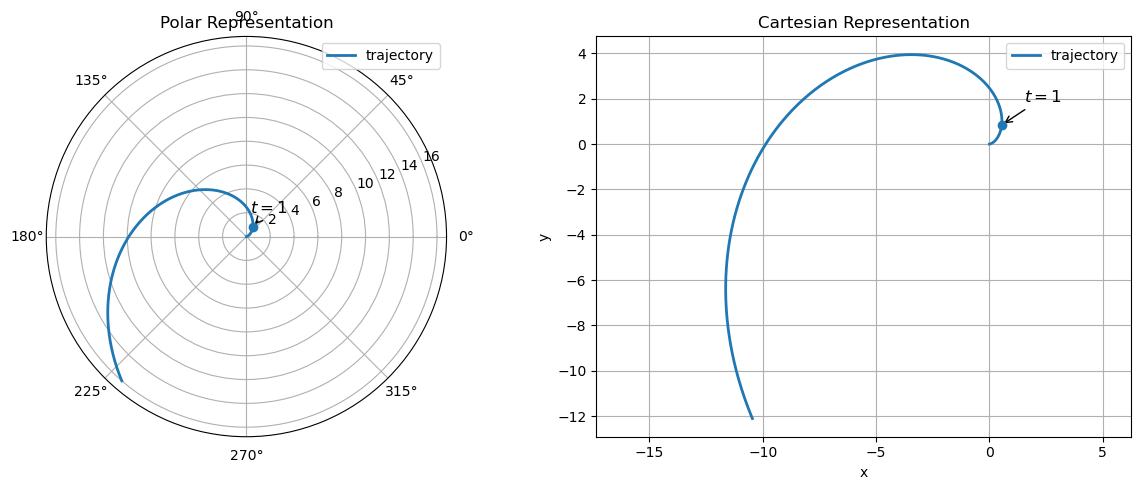

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Particle motion in polar coordinates
# --------------------------------------------------
# Example from the acceleration box:
# r(t) = t^2
# theta(t) = t

t = np.linspace(0, 4, 500)

r = t**2
theta = t

# Convert to Cartesian coordinates
x = r * np.cos(theta)
y = r * np.sin(theta)

# Point to highlight
t0 = 1.0
r0 = t0**2
theta0 = t0

x0 = r0 * np.cos(theta0)
y0 = r0 * np.sin(theta0)

# --------------------------------------------------
# Create side-by-side plots
# --------------------------------------------------
fig = plt.figure(figsize=(12, 5))

# --------------------------------------------------
# Left: Polar representation
# --------------------------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection="polar")

ax1.plot(theta, r, linewidth=2, label="trajectory")
ax1.scatter(theta0, r0, zorder=5)

ax1.annotate(
    r"$t=1$",
    xy=(theta0, r0),
    xytext=(theta0 + 0.4, r0 + 1.0),
    arrowprops=dict(arrowstyle="->"),
    fontsize=12
)

ax1.set_title("Polar Representation")
ax1.grid(True)
ax1.legend(loc="upper right")

# --------------------------------------------------
# Right: Cartesian representation
# --------------------------------------------------
ax2 = fig.add_subplot(1, 2, 2)

ax2.plot(x, y, linewidth=2, label="trajectory")
ax2.scatter(x0, y0, zorder=5)

ax2.annotate(
    r"$t=1$",
    xy=(x0, y0),
    xytext=(x0 + 1.0, y0 + 1.0),
    arrowprops=dict(arrowstyle="->"),
    fontsize=12
)

ax2.set_title("Cartesian Representation")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.axis("equal")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D4.1.5 When Does the $2\dot{r}\dot{\theta}$ Term Matter?

In the expression for acceleration in polar coordinates,

$$
\vec{a} =
(\ddot{r} - r\dot{\theta}^2)\hat{r}
+
(2\dot{r}\dot{\theta} + r\ddot{\theta})\hat{\theta},
$$

the term

$$
2\dot{r}\dot{\theta}
$$

plays an important role whenever **radial motion and angular motion occur simultaneously**.

---

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Key Idea</h3>

The term $2\dot{r}\dot{\theta}$ appears when:

- the particle is moving **radially** ($\dot{r} \neq 0$), and  
- the particle is also **rotating** about the origin ($\dot{\theta} \neq 0$)

</div>

---

### Physical interpretation

This term represents how:

- motion **outward or inward**  
- combined with **rotation**

leads to an additional **tangential acceleration**.

👉 Even if $\ddot{\theta} = 0$, the particle can still have angular acceleration due to this coupling.

---

### Example situations (inertial frame)

---

#### Particle spiraling outward

- A particle moves away from the origin while rotating  
- For example: $r(t)$ increasing, $\theta(t)$ increasing  

Then

$$
2\dot{r}\dot{\theta} > 0
$$

→ additional acceleration in the $\hat{\theta}$ direction

---

#### Particle moving inward while rotating

- A particle moves toward the origin while rotating  

Then

$$
2\dot{r}\dot{\theta} < 0
$$

→ acceleration opposite the direction of rotation

---

#### Central force motion with changing radius

In problems like orbital motion:

- $r$ changes (elliptical orbits)  
- $\theta$ changes  

Even when the force is purely radial, the motion naturally produces this term.

---

<div style="background-color:#e0f7fa; border-left:6px solid #006a80; padding:14px; border-radius:4px;">
<h3 style="margin-top:0;">Example — Outward Spiral Motion</h3>

Suppose

$$
r(t) = t^2, \quad \theta(t) = t.
$$

Then

$$
\dot{r} = 2t, \quad \dot{\theta} = 1
$$

At $t=1$:

$$
2\dot{r}\dot{\theta} = 2(2)(1) = 4
$$

→ significant tangential acceleration even though

$$
\ddot{\theta} = 0
$$

</div>

---

### Important conclusion

This term shows that:

> Angular acceleration does not require $\ddot{\theta} \neq 0$.

It can arise purely from the **interaction between radial and angular motion**.

---

### Connection to earlier ideas

This is another example of a broader principle:

- Motion depends on both **components** and **changing directions**  
- In polar coordinates, these are naturally coupled  

---

### Key takeaway

>Radial motion + rotation → additional tangential acceleration

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D4.1.6 Extension to Three Dimensions — Cylindrical Coordinates  

So far, we have described motion in a plane using **polar coordinates** $(r,\theta)$.  

However, many physical systems involve motion in three dimensions while still retaining **rotational symmetry about an axis**.  

Examples include:  

- motion of a particle around a vertical axis  
- objects moving inside cylinders or pipes  
- rotating machinery  
- charged particles moving in magnetic fields  

In these cases:  

- motion in the $xy$-plane is naturally described using polar coordinates  
- motion along the vertical direction is an independent  cartesian coordinate

This motivates the use of **cylindrical coordinates**, which combine:  

>polar motion in the plane + linear motion along z  

---

<div style="background-color:#e6f0ff; border-left:6px solid #003366; padding:14px; border-radius:4px;">  
<h3 style="margin-top:0;">Definition — Kinematics in Cylindrical Coordinates</h3>  

We describe position using  

$$
(r,\theta,z)
$$  

with unit vectors  

$$
\hat{r}, \quad \hat{\theta}, \quad \hat{k}.
$$  

---

**Position vector**  

$$
\vec{r} = r\hat{r} + z\hat{k}
$$  

---

**Velocity vector**  

$$
\vec{v} =
\dot{r}\hat{r}
+
r\dot{\theta}\hat{\theta}
+
\dot{z}\hat{k}
$$  

---

**Acceleration vector**  

$$
\vec{a} =
(\ddot{r} - r\dot{\theta}^2)\hat{r}
+
(2\dot{r}\dot{\theta} + r\ddot{\theta})\hat{\theta}
+
\ddot{z}\hat{k}
$$  

---

**Key observation**  

- The $z$-motion is **independent** of the radial and angular motion  
- The $r$–$\theta$ components behave exactly as in **polar coordinates**  

</div>  

<hr style="height:2px;border-width:0;color:gray;background-color:gray">